# ***Прогнозирование оттока клиентов телеком-компании***

## Описание проекта
Прогнозная модель для выявления клиентов с высоким риском оттока с целью проактивного удержания 

## Бизнес задача
Своевременно выявлять клиентов, которые могут уйти, чтобы предложить им персональные условия и удержать. Основной фокус - на полноту обнаружения уходящих клиентов (recall), так как важнее не упустить уходящего, чем избежать лишних срабатываний

## Ключевые результаты
- **Лучшая модель:** Logistic Regression с порогом 0.474
- **Recall (отток) 85%** - находим 85% уходящих клиентов (ключевая метрика)
- **Precision (отток) 52%** - каждый второй предсказанный реально уйдет (ложные срабатывания допустимы ради высокого recall) 
- **F1-score (отток): 0.65**
- **Топ-факторы оттока**: интернет провайдер "Fiber Optic", временный клиент, помесячный контракт

## Ключевые выводы 
- Главные факторы риска: Fiber optic, новые клиенты с помесячным контрактом
- Защитные факторы: двухлетний и годовой контракты, отсутствие телефона, долгий срок обслуживания
- Дисбаланс классов: ушедших в 3 раза меньше - использованы взвешенные метрики
- Feature engineering подтвердил ценность: созданный признак `temporary_customer` вошёл в топ важных

## Структура проекта 
- `notebooks/churn_analysis.ipynb` - полный анализ
- `models/logreg_model.pkl` - модель + препроцессор + порог
- `results/predictions.csv` - предсказания на тестовой выборке
- `results/importance.csv` - важность признаков

# 1. Импорт данных и предобработка 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

In [2]:
churn_df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

**Характеристики датасета:**

Размер: 7043 строки, 21 признак 

**Описание признаков датасета:**

- customerID - уникальный айди
- gender - пол
- SeniorCitizen - пожилой человек (0/1)
- Partner	- есть ли партнер (yes/no)
- Dependents - есть ли иждивенцы (yes/no)
- tenure - кол-во месяцев в течение которых клиент сотрудничал с компанией
- PhoneService - наличие телефона. Есть ли у клиента телефонная связь (yes/no)
- MultipleLines - есть ли у клиента много номеров (yes/no/no phone service) No phone service - нет телефонной связи
- InternetService - интернет провайдер клиента
- OnlineSecurity - есть ли у клиента онлайн защита (yes/no/No internet service)  No internet service - нет доступа в интернет
- OnlineBackup - есть ли у клиента онлайн резервное копирование (yes/no/No internet service)  No internet service - нет доступа в интернет
- DeviceProtection - есть ли у клиента защита устройств (yes/no/No internet service)  No internet service - нет доступа в интернет
- TechSupport - есть ли у клиента техническая поддержка (yes/no/No internet service)  No internet service - нет доступа в интернет
- StreamingTV - есть ли у клиента доступ к стриминговому телевидению (yes/no/No internet service)  No internet service - нет доступа в интернет
- StreamingMovies - есть ли у клиента доступ к стриминговым фильмам (yes/no/No internet service)  No internet service - нет доступа в интернет
- Contract - срок действия контракта с клиентом (Month-to-month, One year, Two year)
- PaperlessBilling - есть ли у клиента возможность бумажного биллинга (может ли клиент получать счета на бумаге. yes/no)
- PaymentMethod - способ оплаты (Electronic check, Mailed check, Bank transfer (automatic), Credit card)
- MonthlyCharges - сумма, взимаемая с клиента ежемесячно
- TotalCharges - общая сумма, подлежащая оплате клиентом
- Churn - ушел ли клиент (yes/no) - целевая переменная 

In [3]:
churn_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1.1. Первичный анализ

In [4]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 1.2. Преобразователь типов данных 

Признак TotalCharges должен быть числовым

In [5]:
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')

In [6]:
churn_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Появились NaN — это новые клиенты (tenure = 0). Заполняем нулями 
churn_df['TotalCharges'] = churn_df['TotalCharges'].fillna(0)

# 2. Exploratory Data Analysis (EDA)

In [8]:
churn_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 2.1. Целевая переменная

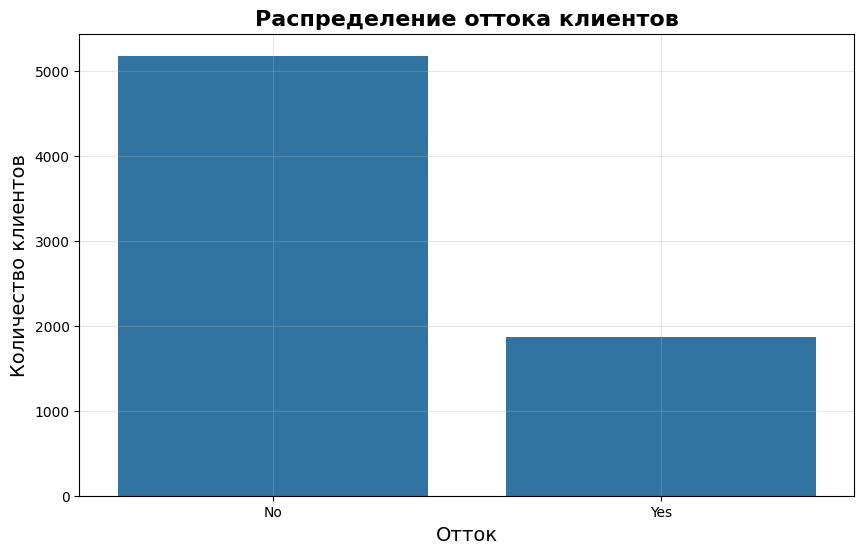

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn_df, x='Churn')
plt.title('Распределение оттока клиентов', fontsize=16, fontweight='bold')
plt.xlabel('Отток', fontsize=14)
plt.ylabel('Количество клиентов', fontsize=14)
plt.grid(alpha=0.3)

---
**Вывод:**  

Наблюдается дисбаланс классов: ушедших клиентов почти в 3 раза меньше, чем оставшихся.
Это означает, что просто accuracy будет плохим показателем, и нужно смотреть на recall (сколько ушедших нашли) и F1-меру

---

## 2.2. Анализ категориальных признаков
### Ключевые признаки

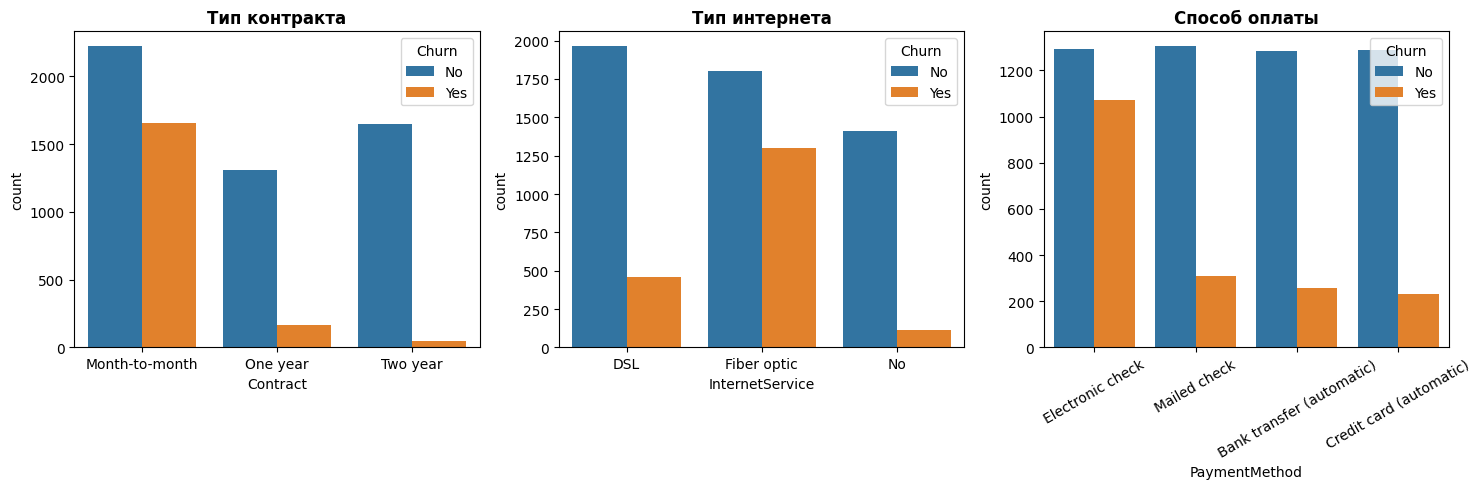

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=churn_df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Тип контракта', fontweight='bold')
sns.countplot(data=churn_df, x='InternetService', hue='Churn', ax=axes[1])
axes[1].set_title('Тип интернета', fontweight='bold')
sns.countplot(data=churn_df, x='PaymentMethod', hue='Churn', ax=axes[2])
axes[2].set_title('Способ оплаты', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout();

### Остальные категориальные признаки 

Остальные признаки были проанализированы, но не включены в отчёт, так как:
- gender - распределение одинаковое среди ушедших и оставшихся
- StreamingTV, StreamingMovies - практически не влияют на отток
- OnlineSecurity, TechSupport - важны не сами по себе, а в сочетании с другими признаками (это учтено при создании новых признаков)
- Partner, Dependents - наличие снижает риск оттока
- PhoneService, MultipleLines - влияние минимально


---
**Вывод:**

По типу контракта: 

- Клиенты с помесячным контрактом уходят значительно чаще остальных
- При двухлетнем контракте отток минимальный

По типу интернета: 

- Тип интернета "Fiber optic" - самый проблемный, доля ушедших здесь заметно выше
- При отсутствии интернета клиенты почти не уходят

По способу оплаты: 

- Electronic check сильно выделяется - в этой группе отток намного выше, чем при других способах оплаты
- Остальные способы (банковский перевод, кредитная карта, чек по почте) показывают схожий и значительно более низкий уровень оттока

Тип контракта, наличие Fiber optic и способ оплаты Electronic check - ключевые индикаторы риска оттока

---

## 2.3 Анализ непрерывных признаков

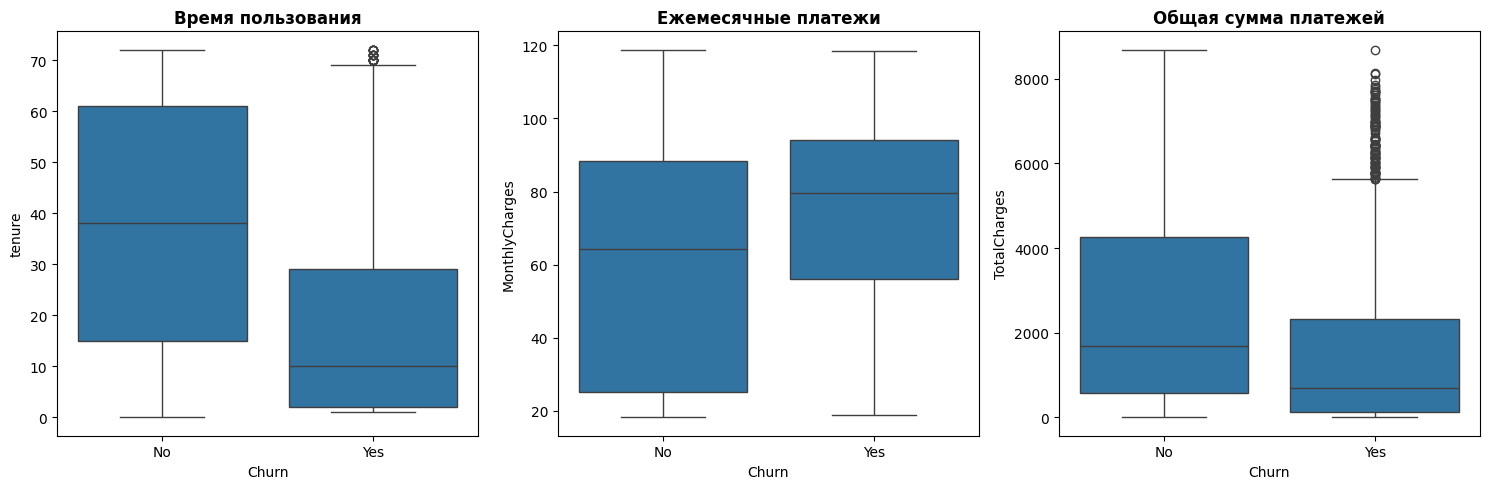

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=churn_df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Время пользования', fontweight='bold')
sns.boxplot(data=churn_df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Ежемесячные платежи', fontweight='bold')
sns.boxplot(data=churn_df, x='Churn', y='TotalCharges', ax=axes[2])
axes[2].set_title('Общая сумма платежей', fontweight='bold')
plt.tight_layout();

---
**Вывод:**

- Ушедшие клиенты имеют значительно меньший срок обслуживания
- Уходящие клиенты в среднем платят больше
- Высокие ежемесячные платежи - фактор риска
- У уходящих клиентов общая сумма платежей ниже, это вытекает из малого срока обслуживания

---

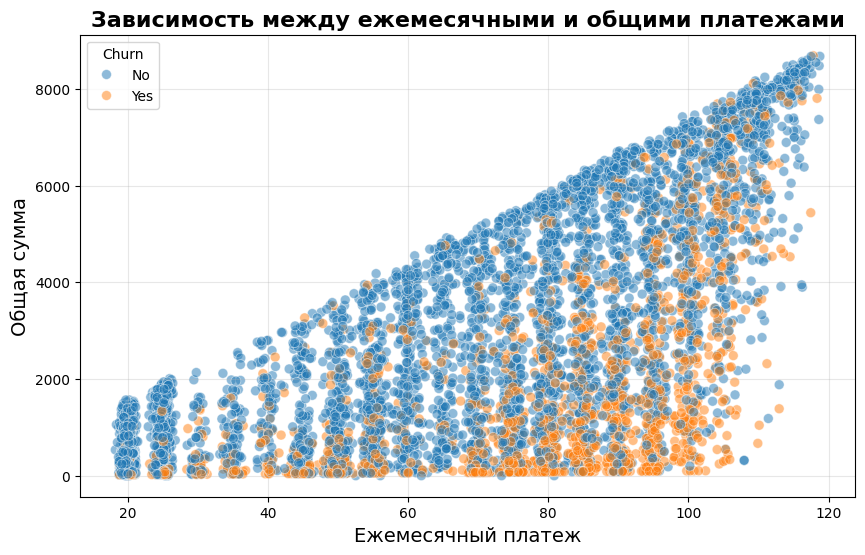

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=churn_df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5, s=50)
plt.title('Зависимость между ежемесячными и общими платежами', fontsize=16, fontweight='bold')
plt.xlabel('Ежемесячный платеж', fontsize=14)
plt.ylabel('Общая сумма', fontsize=14)
plt.grid(alpha=0.3)

---
**Вывод:**

На графике чётко выделяется группа клиентов с высокими ежемесячными платежами, но низкой общей суммой

Это новые клиенты с дорогими тарифами - группа повышенного риска

---

In [13]:
# Числовой признак оттока где 1 это клиент покинул компанию
churn_df['Churn_num'] = churn_df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

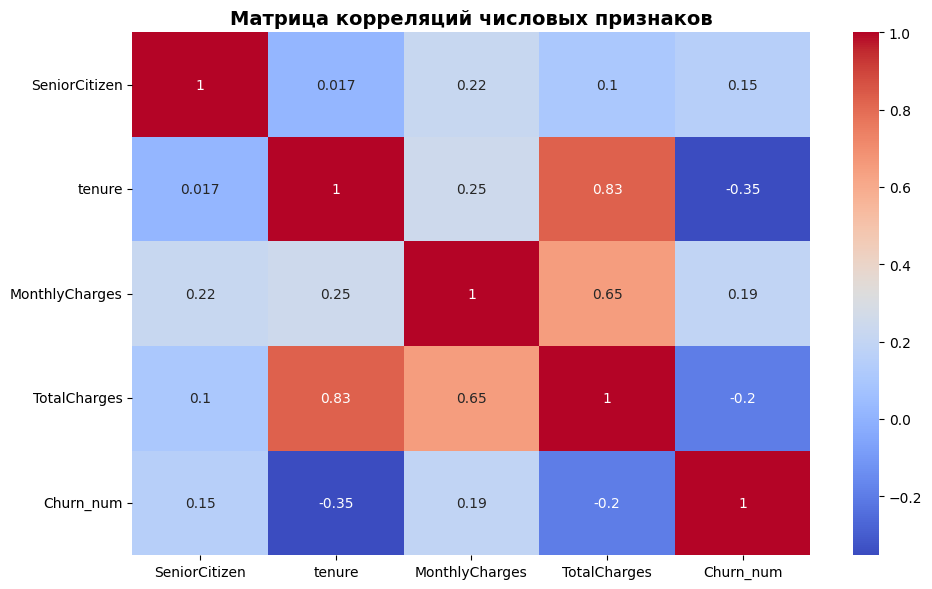

In [14]:
numeric_cols = churn_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
sns.heatmap(data=churn_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout();

---
**Вывод:**

- tenure имеет заметную отрицательную связь с оттоком - чем дольше клиент с компанией, тем меньше вероятность ухода
- MonthlyCharges слабо положительно связан с оттоком - высокие платежи немного повышают риск
- TotalCharges сильно коррелирует с tenure (чем дольше клиент, тем больше общая сумма)


Ключевой вывод: tenure - самый сильный среди числовых признаков

---

## 2.4 Детальный анализ комбинаций признаков (сводные таблицы)

In [15]:
pd.pivot_table(churn_df, index=['SeniorCitizen', 'Partner', 'Dependents'], values='Churn_num', aggfunc=['count', 'mean'])

count      mean
                                 Churn_num Churn_num
SeniorCitizen Partner Dependents                    
0             No      No              2719  0.311512
                      Yes              353  0.212465
              Yes     No              1163  0.208083
                      Yes             1666  0.137455
1             No      No               561  0.491979
                      Yes                8  0.250000
              Yes     No               490  0.363265
                      Yes               83  0.240964

---
**Вывод:**

- Пожилые одинокие клиенты (без партнёра и иждивенцев) уходят в 49% случаев
- Наличие партнёра или иждивенцев снижает отток среди пожилых

---

In [16]:
pd.pivot_table(churn_df, index=['tenure', 'Contract'], values='Churn_num', aggfunc=['count', 'mean'])

count      mean
                      Churn_num Churn_num
tenure Contract                          
0      One year               1  0.000000
       Two year              10  0.000000
1      Month-to-month       604  0.629139
       One year               7  0.000000
       Two year               2  0.000000
...                         ...       ...
71     One year              28  0.000000
       Two year             137  0.036496
72     Month-to-month         2  0.000000
       One year              17  0.117647
       Two year             343  0.011662

[218 rows x 2 columns]

---
**Вывод:**

- Новые клиенты (tenure = 1 месяц) с помесячным контрактом уходят в 63% случаев
- Чем дольше клиент с компанией, тем ниже отток, особенно при долгосрочных контрактах

---

In [17]:
pd.pivot_table(churn_df, index='PaymentMethod', values='Churn_num', aggfunc=['count', 'mean']) 

,count,mean
,Churn_num,Churn_num
PaymentMethod,,
Bank transfer (automatic),1544,0.167098
Credit card (automatic),1522,0.152431
Electronic check,2365,0.452854
Mailed check,1612,0.191067


---
**Вывод:**

- Electronic check - самый рискованный способ оплаты (45% оттока)
- Остальные способы (банковский перевод, кредитная карта, чек по почте) показывают отток 15-19%

---

In [18]:
pd.pivot_table(churn_df, 
               index=['InternetService'], 
               values=['MonthlyCharges', 'TotalCharges'], 
               aggfunc=['mean', 'median']).T

InternetService                DSL  Fiber optic          No
mean   MonthlyCharges    58.102169    91.500129   21.079194
       TotalCharges    2115.411338  3205.304570  662.604784
median MonthlyCharges    56.150000    91.675000   20.150000
       TotalCharges    1596.600000  2660.650000  519.200000

---
**Вывод:**
- Fiber optic это самый дорогой тариф: средний платёж: 91.5 в месяц 
- Высокая стоимость Fiber optic объясняет его высокий отток - клиенты чувствительны к цене

---

In [19]:
pd.pivot_table(churn_df, index=['InternetService', 'OnlineSecurity'], values='Churn_num', aggfunc=['count', 'mean'])

count      mean
                                    Churn_num Churn_num
InternetService OnlineSecurity                         
DSL             No                       1241  0.279613
                Yes                      1180  0.094915
Fiber optic     No                       2257  0.493576
                Yes                       839  0.218117
No              No internet service      1526  0.074050

---
**Вывод:**

Отток среди клиентов с Fiber optic без OnlineSecurity составляет 49%, а с услугой - 22%

---

## 2.5. Итоговые выводы EDA 

**Ключевые факторы оттока:**

1. **Тип контракта**
   
   Самый сильный фактор. Клиенты с помесячным контрактом уходят значительно чаще, чем с годовым или двухлетним

2. **Интернет-провайдер**

   Клиенты с Fiber optic уходят заметно чаще остальных. Это связано с высокой стоимостью тарифа

3. **Способ оплаты**

   Electronic check - самый рискованный способ оплаты, отток в этой группе намного выше

4. **Срок обслуживания (tenure)**

   Чем меньше клиент с компанией, тем выше вероятность оттока. Основная группа риска - клиенты со сроком менее года

5. **Пожилые одинокие клиенты**

   Пожилые одинокие клиенты (без партнёра и иждивенцев) - группа повышенного риска

6. **Дополнительные услуги**

    Для клиентов с Fiber optic наличие любой дополнительной услуги (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) снижает отток примерно в 2 раза

    Например, отток среди клиентов с Fiber optic без OnlineSecurity составляет 49%, а с услугой - 22%. Аналогичная картина наблюдается для других сервисов
   

# 3. Создание новых признаков (Feature Engineering)

In [20]:
# Количество подключенных услуг 
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
churn_df['num_services'] = churn_df[service_columns].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [21]:
# Клиенты без иждивенцев и партнера
churn_df['IsAlone'] = ((churn_df['Dependents'] == 'No') & 
                       (churn_df['Partner'] == 'No')).astype(int) 

In [22]:
# Одинокий пожилой клиент 
churn_df['senior_alone'] = ((churn_df['SeniorCitizen'] == 1) &
                            (churn_df['IsAlone'] == 1)).astype(int)

In [23]:
# Клиент у которого интернет провайдер Fiber optic и не подключена ни одна услуга - высокий шанс оттока 
churn_df['fiber_without_services'] = ((churn_df['InternetService'] == 'Fiber optic') & 
                                      (churn_df['OnlineSecurity'] == 'No') & 
                                      (churn_df['OnlineBackup'] == 'No') & 
                                      (churn_df['DeviceProtection'] == 'No') & 
                                      (churn_df['TechSupport'] == 'No')).astype(int)

In [24]:
# Признак "временный клиент" - короткий tenure + помесячный контракт
churn_df['temporary_customer'] = ((churn_df['tenure'] < 12) & 
                                  (churn_df['Contract'] == 'Month-to-month')).astype(int)

---

На основе EDA добавлены признаки, отражающие группы риска:
- `num_services` - количество подключенных услуг
- `IsAlone` - одиночки (без партнера и иждивенцев)
- `senior_alone` - пожилые одинокие клиенты
- `fiber_without_services` - Fiber optic без доп. услуг
- `temporary_customer` - новые клиенты с помесячным контрактом

---

# 4. Подготовка данных к моделированию

## 4.1. Разделение на тренировочную и тестовую выборки 

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = churn_df.drop(['Churn', 'Churn_num', 'customerID'], axis=1)
y = churn_df['Churn_num']

In [27]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,num_services,IsAlone,senior_alone,fiber_without_services,temporary_customer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,1,0,0,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,2,1,0,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,2,1,0,0,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,3,1,0,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,0,1,0,1,1


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'num_services', 'IsAlone',
       'senior_alone', 'fiber_without_services', 'temporary_customer'],
      dtype='object')

## 4.2. Создание пайплайна препроцессинга

In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [31]:
# Классификация признаков
cat_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'] # Категориальные признаки которые нужно превратить в dummie переменные
bin_features = ['SeniorCitizen', 'IsAlone', 'fiber_without_services', 'temporary_customer', 'senior_alone'] # Категориальные переменные которые уже равны 0 или 1 и их не нужно превращать в dummie 
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services'] # Непрерывные признаки 

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features), # Масштабирование числовых
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features), # OneHotEncoding для категориальных
        ('bin', 'passthrough', bin_features) # Бинарные оставляем как есть
])

In [33]:
X_train_processed = preprocessor.fit_transform(X_train) 
feature_names = preprocessor.get_feature_names_out() 
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index) 
X_train_processed.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,num__num_services,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,bin__SeniorCitizen,bin__IsAlone,bin__fiber_without_services,bin__temporary_customer,bin__senior_alone
1695,0.881078,0.195927,0.654503,0.517373,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1095,-1.284263,0.522755,-0.974042,-0.560898,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3889,-0.793997,-1.509551,-0.894986,-1.100034,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3667,-0.344587,1.053643,-0.010497,0.517373,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2902,-1.079985,0.308740,-0.810567,-0.560898,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


In [34]:
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
X_test_processed.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,num__num_services,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,bin__SeniorCitizen,bin__IsAlone,bin__fiber_without_services,bin__temporary_customer,bin__senior_alone
185,-1.284263,-1.327058,-0.998650,-1.100034,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2715,0.349957,-1.312127,-0.569758,-1.100034,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3825,0.799367,-1.507892,-0.554199,-1.100034,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1807,-1.284263,0.383397,-0.975896,-0.560898,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
132,1.412199,-0.472660,0.429431,-0.560898,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# 5. Построение и оценка моделей 
## 5.1 Сравнение базовых моделей 

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_val_score

In [36]:
models = {'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'), 
         'SVC': SVC(class_weight='balanced'), 
         'RandomForest': RandomForestClassifier(class_weight='balanced'), 
         'XGBoost': XGBClassifier(), 
         'CatBoost': CatBoostClassifier(verbose=0, random_state=42)}

In [37]:
result_f1 = {}
result_auc = {}

for name, model in models.items():
    scores_f1 = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='f1')
    result_f1[name] = scores_f1.mean()
    
    scores_auc = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='roc_auc')
    result_auc[name] = scores_auc.mean()

In [38]:
print('F1-Scores:')
for name, score in result_f1.items():
    print(f'{name}: {score}')

print('\n')
    
print('AUC-ROC Scores:')
for name, score in result_auc.items():
    print(f'{name}: {score}')


F1-Scores:
LogisticRegression: 0.614491403613781
SVC: 0.6124155906796422
RandomForest: 0.539025490980603
XGBoost: 0.5500260472630856
CatBoost: 0.5733690688272739


AUC-ROC Scores:
LogisticRegression: 0.8406000223056619
SVC: 0.8225122548368766
RandomForest: 0.8187054218691081
XGBoost: 0.8133334749565837
CatBoost: 0.8354474144020225


---
### Выводы и интерпретация метрик: 
### Выбор метрик: 
- accuracy бесполезен при дисбалансе, поэтому не используется
- F1-Score - баланс между Precision ("сколько из предсказанных реально уйдут") и Recall ("сколько уходящих находим")
- AUC-ROC - показывает, насколько хорошо модель отличает уходящих от остающихся

### Результаты моделей: 
- LogisticRegression - лучший баланс метрик (F1=0.61, AUC=0.84)
- SVC - такой же F1 (0.61), но уступает по AUC и медленнее в обучении
- CatBoost - хороший AUC (0.834), близкий к лидеру, но F1 ниже
- XGBoost и RandomForest - уступают по обеим метрикам

*KNN не использовался, тк метод чувствителен к большому количеству категориальных признаков (после OneHotEncoding их стало 44) и показал низкие результаты на предварительных тестах*


**Вывод:** Logistic Regression выбрана как базовая модель для дальнейшего тюнинга

---

## 5.2 LogisticRegression с подбором гиперпараметров 

In [39]:
from sklearn.model_selection import RandomizedSearchCV

In [40]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [41]:
param_dist_logreg = {
    'penalty': ['l1', 'l2', 'elasticnet'], 
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'class_weight': ['balanced', None]
}

In [42]:
logreg = LogisticRegression(max_iter=1000)

In [43]:
random_search_logreg = RandomizedSearchCV(estimator=logreg, 
                                   param_distributions=param_dist_logreg, 
                                   n_iter=20,
                                   cv=5, 
                                   scoring='f1',
                                   random_state=42, 
                                   n_jobs=-1
                                )

In [44]:
random_search_logreg.fit(X_train_processed, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_distributions,"{'C': [0.01, 0.05, ...], 'class_weight': ['balanced', None], 'penalty': ['l1', 'l2', ...]}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [45]:
random_search_logreg.best_params_

{'penalty': 'l2', 'class_weight': 'balanced', 'C': 100}

In [46]:
preds_logreg = random_search_logreg.predict(X_test_processed)

In [47]:
print(classification_report(y_test, preds_logreg))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1539
           1       0.54      0.82      0.65       574

    accuracy                           0.76      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.81      0.76      0.77      2113



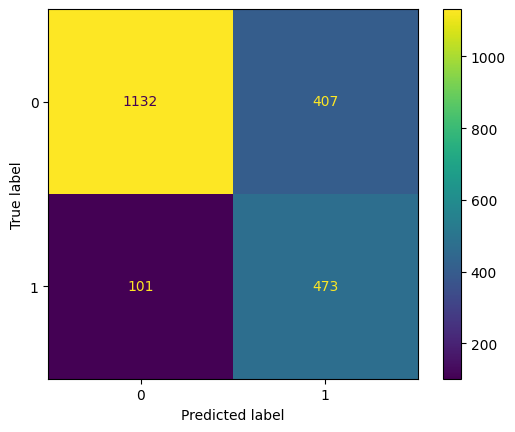

In [48]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_logreg)

---
**Вывод:**

Результаты на тесте:
- Recall (отток): 82% (нашли 473 из 574 ушедших)
- Precision (отток): 54% (каждый второй предсказанный ушёл)
- F1-score (отток): 0.65

Модель находит 82% уходящих клиентов (473 из 574). При этом из тех, кого она считает уходящими, реально уходит каждый второй. Для выявления 473 ушедших потребуется дополнительно проверить 408 ложных срабатываний

---

## 5.3. SVM с подбором гиперпараметров

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],                  
    'kernel': ['linear', 'rbf', 'sigmoid'],               
    'gamma': ['scale', 'auto'],             
    'class_weight': ['balanced']              
}

In [51]:
svm = SVC(random_state=42, max_iter=1000)

In [52]:
grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=3,                                     
    scoring='f1',
    n_jobs=-1
)

In [53]:
grid_search_svm.fit(X_train_processed, y_train)

,estimator,SVC(max_iter=...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': ['balanced'], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [54]:
grid_search_svm.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

In [55]:
preds_svm = grid_search_svm.predict(X_test_processed)

In [56]:
print(classification_report(y_test, preds_svm))

              precision    recall  f1-score   support

           0       0.86      0.62      0.72      1539
           1       0.42      0.73      0.53       574

    accuracy                           0.65      2113
   macro avg       0.64      0.67      0.63      2113
weighted avg       0.74      0.65      0.67      2113



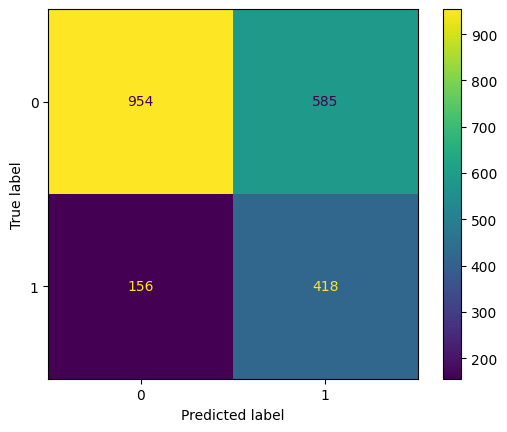

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_svm)

---
**Вывод:**

Результаты на тесте:

- Recall (отток): 73% (нашли 418 из 574 ушедших)
- Precision (отток): 42%
- F1-score (отток): 0.53

Сравнение с Logistic Regression:
- Logistic Regression находила 82% ушедших, SVM - 73%
- Logistic Regression давала 54% точности, SVM - 42%
- SVM обучается дольше и уступает по всем метрикам

SVM не подходит для данной задачи. Логистическая регрессия показывает лучшие результаты при меньших вычислительных затратах

---

## 5.4. CatBoost с подбором гиперпараметров  

In [58]:
param_grid_catboost = {
    'iterations': [300, 500],
    'learning_rate': [0.03, 0.05], 
    'depth': [4, 6],
    'l2_leaf_reg': [1, 5]
}

In [59]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
scale_pos_weight

2.806949806949807

In [60]:
catboost = CatBoostClassifier(verbose=0, random_state=42, scale_pos_weight=scale_pos_weight)

In [61]:
grid_search_catboost = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid_catboost,
    cv=3,                                     
    scoring='f1',
    n_jobs=-1
)

In [62]:
grid_search_catboost.fit(X_train_processed, y_train)

,estimator,<catboost.cor...001DC929FEF80>
,param_grid,"{'depth': [4, 6], 'iterations': [300, 500], 'l2_leaf_reg': [1, 5], 'learning_rate': [0.03, 0.05]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [63]:
grid_search_catboost.best_params_

{'depth': 6, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.03}

In [64]:
preds_catboost = grid_search_catboost.predict(X_test_processed)

In [65]:
print(classification_report(y_test, preds_catboost))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1539
           1       0.54      0.81      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



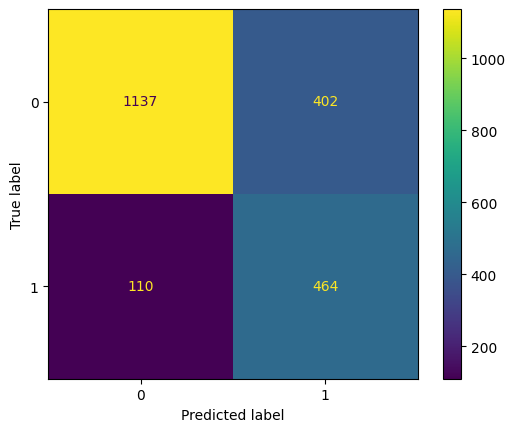

In [66]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_catboost)

---
**Вывод:**

- Recall (отток): 81% (найдено 464 из 574 ушедших)
- Precision (отток): 54%
- F1-score (отток): 0.64

Сравнение с Logistic Regression:
- Logistic Regression находила 82% ушедших, CatBoost - 81% (незначительно ниже)
- Logistic Regression давала 54% точности, CatBoost - 54% (также)
- CatBoost показывает близкие результаты, но немного уступает по recall

CatBoost даёт результаты, близкие к Logistic Regression. Модель можно рассматривать как альтернативу, но для финального решения выбрана Logistic Regression из-за простоты и интерпретируемости

---

## 5.5. Оптимизация порога классификации для Logistic Regression

In [67]:
from sklearn.metrics import RocCurveDisplay, roc_curve

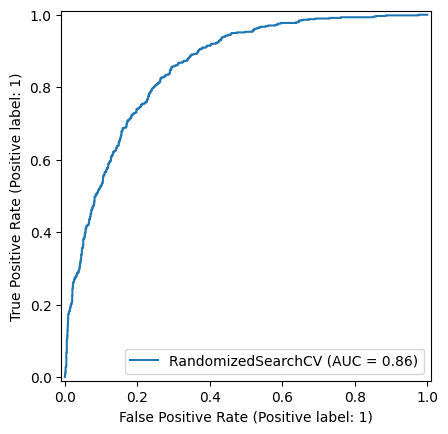

In [68]:
RocCurveDisplay.from_estimator(random_search_logreg, X_test_processed, y_test)

In [69]:
preds_proba_logreg = random_search_logreg.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, preds_proba_logreg)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f'Лучший порог: {best_threshold}')
print(f'Recall (TPR) при этом пороге: {tpr[best_idx]}')
print(f'FPR при этом пороге: {fpr[best_idx]}')

Лучший порог: 0.473861947324526
Recall (TPR) при этом пороге: 0.8554006968641115
FPR при этом пороге: 0.2936972059779077


In [70]:
preds_logreg_best = (preds_proba_logreg > best_threshold).astype(int)

In [71]:
print(classification_report(y_test, preds_logreg_best))

              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1539
           1       0.52      0.85      0.65       574

    accuracy                           0.75      2113
   macro avg       0.72      0.78      0.72      2113
weighted avg       0.82      0.75      0.76      2113



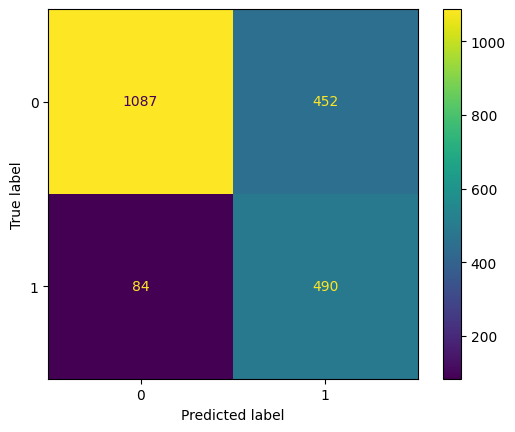

In [72]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_logreg_best)

---
**Вывод** 

ROC-AUC модели составляет 0.85, что говорит о хорошей способности модели разделять классы

Для нахождения оптимального баланса между полнотой (recall) и точностью (precision) был подобран порог, максимизирующий разницу TPR и FPR

Результаты: 

- Оптимальный порог: 0.474
- Recall (отток): 85% (найдено 490 из 574 ушедших)
- Precision (отток): 52%
- F1-score (отток): 0.65

---

## 5.6. Итоговый вывод 

В ходе экспериментов были протестированы 5 моделей. Лучшие результаты показали Logistic Regression и CatBoost.

| Модель | Recall | Precision | F1 |
|--------|--------|-----------|-----|
| Logistic Regression (порог 0.474) | 85% | 52% | 0.65 |
| CatBoost | 81% | 54% | 0.64 |
| SVM | 73% | 42% | 0.53 |

**Лучшая модель: Logistic Regression с порогом 0.474**

Модель находит 85% уходящих клиентов (490 из 574). Точность предсказания составляет 52% - каждый второй помеченный как «уходящий» действительно уходит.  Для выявления 490 ушедших потребуется дополнительно проверить 452 клиента, которые ошибочно отнесены к группе риска


## 6. Анализ важности признаков (Feature Importance)

In [73]:
feature_importance = pd.DataFrame({
    'feature': X_test_processed.columns, 
    'importance': random_search_logreg.best_estimator_.coef_[0]
})

In [74]:
feature_importance['abs_importance'] = abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('abs_importance', ascending=False)
feature_importance.head(15)

,feature,importance,abs_importance
10,cat__InternetService_Fiber optic,2.361660,2.361660
1,num__MonthlyCharges,-2.009692,2.009692
25,cat__Contract_Two year,-1.741139,1.741139
8,cat__MultipleLines_No phone service,-0.949196,0.949196
3,num__num_services,0.914591,0.914591
33,bin__temporary_customer,0.764143,0.764143
0,num__tenure,-0.738842,0.738842
9,cat__MultipleLines_Yes,0.596705,0.596705
24,cat__Contract_One year,-0.586138,0.586138
23,cat__StreamingMovies_Yes,0.539302,0.539302


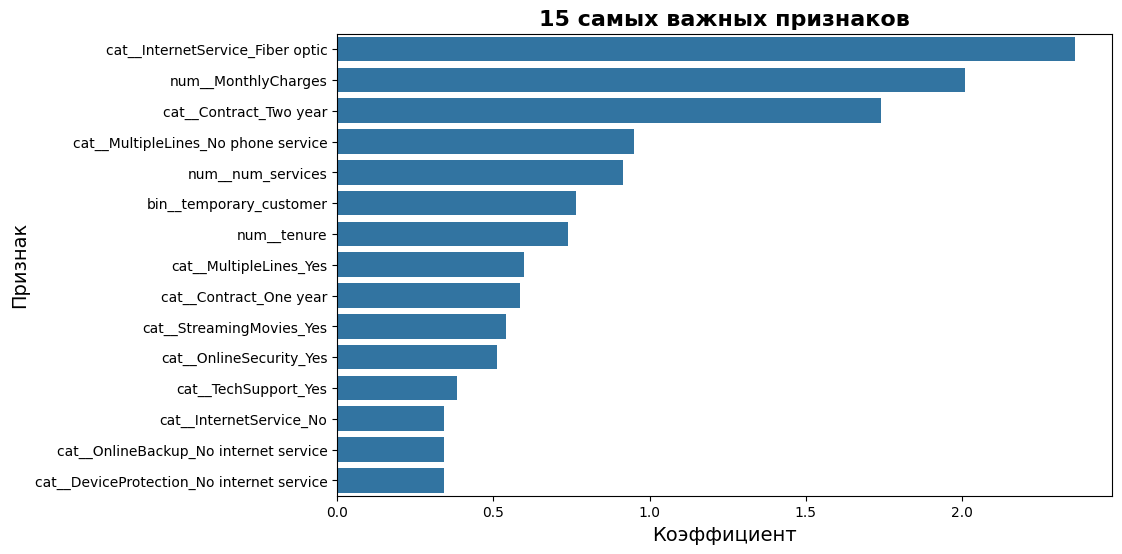

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='abs_importance', y='feature')
plt.title('15 самых важных признаков', fontsize=16, fontweight='bold')
plt.xlabel('Коэффициент', fontsize=14)
plt.ylabel('Признак', fontsize=14);

---
### Результаты анализа важности признаков:  

#### **Топ 5 самых важных признаков:** 
| Признак | Коэффициент | Влияние |
|---------|-------------|---------|
| Fiber optic | +2.36 | Сильно повышает риск оттока - самый важный фактор |
| MonthlyCharges | -2.01 | Отрицательный коэффициент (из-за корреляции с Fiber optic) |
| Contract_Two year | -1.74 | Двухлетний контракт - сильно снижает риск |
| MultipleLines_No phone service | -0.95 | Отсутствие телефона снижает риск |
| num_services | +0.91 | Больше услуг = выше риск |

#### Что увеличивает риск оттока:
- Fiber optic (+ 2.36) - клиенты с интернет провайдером "Fiber " уходят чаще всего
- num_services (+ 0.91) - коэффициент положительный, но зависимость нелинейная:  
  максимальный риск (46%) при 1 услуге, далее с ростом услуг риск снижается (до 5% при 6 услугах)
- temporary_customer (+ 0.76) - новые клиенты с помесячным контрактом
- MultipleLines_Yes (+ 0.60) - наличие нескольких номеров у клиента
- StreamingMovies_Yes (+ 0.54) - наличие доступа к стриминговым фильмам

#### Что снижает риск оттока:
- Contract_Two year (-1.74) - двухгодовой контракт снижает риск оттока
- MultipleLines_No phone service (-0.95) - Отсутствие телефона
- tenure (- 0.74) - чем дольше клиент, тем ниже риск
- Contract_One year (-0.59) - годовой контракт тоже снижает риск оттока
- OnlineSecurity_Yes (-0.51) - наличие онлайн-защиты
- TechSupport_Yes (-0.39) - наличие техподдержки
- InternetService_No (-0.34) - отсутствие интернета

#### Важное замечание:
Отрицательный коэффициент у MonthlyCharges (-2.01) объясняется сильной корреляцией с Fiber optic. В EDA видно, что уходящие платят больше, но модель не может разделить эти эффекты. Для интерпретации важности используется модуль коэффициента

#### Вывод: 
Модель опирается на логичные бизнес-факторы: тип интернета, тип контракта, срок обслуживания и наличие дополнительных услуг. Созданные признаки (`temporary_customer`) подтвердили свою ценность, войдя в топ важных

---

## 7. Сохранение модели и результатов

In [76]:
import joblib

In [77]:
model_with_threshold = {
    'model': random_search_logreg.best_estimator_, 
    'best_threshold': best_threshold, 
    'preprocessor': preprocessor, 
    'feature_names': feature_names   
}

In [78]:
joblib.dump(model_with_threshold, '../models/logreg_model.pkl')

['../models/logreg_model.pkl']

In [79]:
predictions_df = pd.DataFrame({
    'real_churn': y_test.values,
    'predicted_churn': preds_logreg_best
})

In [80]:
predictions_df.to_csv('../results/predictions.csv', index=False, encoding='utf-8')

In [81]:
importance_df = feature_importance.sort_values('abs_importance', ascending=False)

In [82]:
importance_df.to_csv('../results/importance.csv', index=False, encoding='utf-8')